# 1. SETUP ENVIRONMENT

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Install library
!pip install -q pydicom PyWavelets scikit-image

# Import library
import os
import glob
import json
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project Path
PROJECT_PATH = "/content/drive/MyDrive/TugasAkhirKayla"

DATASET_PATH = os.path.join(PROJECT_PATH, "Dataset")
OUTPUT_PATH  = os.path.join(PROJECT_PATH, "Output")

os.makedirs(OUTPUT_PATH, exist_ok=True)

import sys

if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)

# Import module

from Modules import (
    preprocessing,
    dwt,
    energy,
    adaptive,
    embedding,
    extraction,
    evaluation,
    utils
)

modules = [
    preprocessing,
    dwt,
    energy,
    adaptive,
    embedding,
    extraction,
    evaluation,
    utils
]

for module in modules:
    importlib.reload(module)

print("Semua modul berhasil dimuat.")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 8.0 MB/s eta 0:00:00
Semua modul berhasil dimuat.


In [2]:
# EXPERIMENT CONFIGURATION

SCENARIO = "S2"

SCENARIOS = {

    "S1": {
        "description": "3 Patients × 5 Slices",
        "patients": [
            "LIDC-IDRI-0001",
            "LIDC-IDRI-0002",
            "LIDC-IDRI-0003"
        ],
        "selection": "all"
    },

    "S2": {
        "description": "15 Patients × 1 Slice",
        "patients": "all",
        "selection": "middle"
    }

}

In [3]:
# LOAD DATASET

def load_dataset(dataset_path, config):

    selected_files = []

    # Tentukan daftar pasien

    if config["patients"] == "all":

        patient_folders = sorted(

            folder

            for folder in glob.glob(
                os.path.join(dataset_path, "*")
            )

            if os.path.isdir(folder)

        )

    else:

        patient_folders = [

            os.path.join(dataset_path, patient)

            for patient in config["patients"]

        ]

    # Ambil file sesuai skenario

    for patient_folder in patient_folders:

        files = sorted(

            glob.glob(
                os.path.join(patient_folder, "*.dcm")
            )

        )

        if len(files) == 0:

            continue

        # Semua slice
        if config["selection"] == "all":

            selected_files.extend(files)

        # Slice tengah
        elif config["selection"] == "middle":

            middle = len(files) // 2

            selected_files.append(
                files[middle]
            )

    return selected_files

In [4]:
# LOAD SCENARIO

config = SCENARIOS[SCENARIO]

selected_files = load_dataset(
    DATASET_PATH,
    config
)

print("DATASET INFORMATION")

print(f"Scenario    : {SCENARIO}")
print(f"Description : {config['description']}")
print(f"Total Images: {len(selected_files)}")

print()

for file in selected_files:

    print(os.path.basename(file))

DATASET INFORMATION
Scenario    : S2
Description : 15 Patients × 1 Slice
Total Images: 15

1-067.dcm
1-131.dcm
1-070.dcm
1-121.dcm
1-067.dcm
1-067.dcm
1-073.dcm
1-067.dcm
1-128.dcm
1-139.dcm
1-064.dcm
1-064.dcm
1-063.dcm
1-057.dcm
1-105.dcm


# PROCESS SINGLE IMAGE

In [ ]:
def process_single_image(filepath):

    result = {}
    # STEP 1 - LOAD DICOM

    dataset = preprocessing.load_dicom(filepath)

    image = preprocessing.get_pixel_array(dataset)

    metadata = preprocessing.extract_metadata(dataset)

    metadata_string = json.dumps(metadata, indent=4)

    # STEP 2 - PREPROCESSING

    normalized_image = preprocessing.normalize_image(image)

    # STEP 3 - DWT

    LL, LH, HL, HH = dwt.dwt_decompose(
        normalized_image
    )

    # STEP 4 - ENERGY

    energies = energy.calculate_all_energies(
        LL,
        LH,
        HL,
        HH
    )

    # STEP 5 - ADAPTIVE SUBBAND

    selected_name, selected_subband = (
        adaptive.select_adaptive_subband(
            LH,
            HL
        )
    )

    # STEP 6 - PREPARE PAYLOAD

    payload = embedding.prepare_payload(metadata_string)

    payload_length = len(payload)

    # STEP 7 - CAPACITY CHECK

    try:

      capacity = embedding.capacity_check(
          payload,
          selected_subband
      )

    except ValueError as e:

      result["Status"] = "Capacity Exceeded"

      result["Error"] = str(e)

      return result

    # STEP 8 - EMBEDDING

    scaled_subband = embedding.prepare_subband(
        selected_subband
    )

    embedded_scaled_subband = embedding.embed_lsb(
        scaled_subband,
        payload
    )

    embedded_subband = embedding.restore_subband(
        embedded_scaled_subband
    )

    # STEP 9 - RECONSTRUCTION

    if selected_name == "LH":

      reconstructed = dwt.dwt_reconstruct(
          LL,
          embedded_subband,
          HL,
          HH
      )

    else:
      reconstructed = dwt.dwt_reconstruct(
          LL,
          LH,
          embedded_subband,
          HH
      )

    embedded_image = np.clip(
        reconstructed,
        0,
        255
    ).astype(np.uint8)

    # STEP 10 - IMAGE QUALITY EVALUATION

    report = evaluation.evaluation_report(
        normalized_image,
        embedded_image
    )

    result["MSE"] = report["MSE"]

    result["PSNR (dB)"] = report["PSNR"]

    result["SSIM"] = report["SSIM"]

    # STEP 11 - METADATA EXTRACTION & BER

    # Pilih kembali subband yang telah disisipi
    if selected_name == "LH":
      selected_embedded_subband = embedded_subband
    else:
      selected_embedded_subband = embedded_subband

    # Ekstraksi metadata
    extracted_metadata = extraction.extract_metadata(
        selected_embedded_subband
    )

    # Payload asli (tanpa header)
    original_binary = embedding.string_to_binary(
        metadata_string
    )

    # Payload hasil ekstraksi
    binary_stream = extraction.extract_lsb(
        selected_embedded_subband
    )

    extracted_binary = extraction.extract_payload(
        binary_stream
    )

    # Hitung BER
    ber = evaluation.calculate_ber(
        original_binary,
        extracted_binary
    )

    # SAVE BASIC INFORMATION

    result["Patient ID"] = metadata["Patient ID"]
    result["Filename"] = os.path.basename(filepath)
    result["Selected Subband"] = selected_name
    result["Energy (LH)"] = energies["LH"]
    result["Energy (HL)"] = energies["HL"]
    result["Status"] = "Success"
    result["Payload Length (bits)"] = capacity["required"]
    result["Capacity (bits)"] = capacity["capacity"]
    result["Remaining Capacity (bits)"] = capacity["remaining"]
    result["Capacity Utilization (%)"] = round(
        (capacity["required"] / capacity["capacity"]) * 100,
        2
    )
    result["MSE"] = report["MSE"]
    result["PSNR (dB)"] = report["PSNR"]
    result["SSIM"] = report["SSIM"]
    result["Extraction Status"] = (
        "Success"
        if metadata_string == extracted_metadata
        else "Failed"
    )
    result["BER"] = ber

    return result

In [ ]:
results = []

print(f"Results initialized: {len(results)}")

Results initialized: 0


In [ ]:
# 5. RUN BATCH EXPERIMENTresults = []

print("Starting Batch Experiment...")
print(f"Scenario : {SCENARIO}")
print(f"Images   : {len(selected_files)}")

for i, filepath in enumerate(selected_files, start=1):

    print(f"[{i}/{len(selected_files)}] {os.path.basename(filepath)}")

    try:

        result = process_single_image(filepath)

    except Exception as e:

        result = {
            "Filename": os.path.basename(filepath),
            "Status": "Failed",
            "Error": str(e)
        }

    results.append(result)

print("Batch Experiment Completed")

Starting Batch Experiment...
Scenario : S2
Images   : 15
[1/15] 1-067.dcm
[2/15] 1-131.dcm
[3/15] 1-070.dcm
[4/15] 1-121.dcm
[5/15] 1-067.dcm
[6/15] 1-067.dcm
[7/15] 1-073.dcm
[8/15] 1-067.dcm
[9/15] 1-128.dcm
[10/15] 1-139.dcm
[11/15] 1-064.dcm
[12/15] 1-064.dcm
[13/15] 1-063.dcm
[14/15] 1-057.dcm
[15/15] 1-105.dcm
Batch Experiment Completed


In [ ]:
# 6. RESULTS DATAFRAME

results_df = pd.DataFrame(results)

column_order = [

    # File Information
    "Patient ID",
    "Filename",

    # Adaptive Selection
    "Selected Subband",
    "Energy (LH)",
    "Energy (HL)",

    # Payload Information
    "Payload Length (bits)",
    "Capacity (bits)",
    "Remaining Capacity (bits)",
    "Capacity Utilization (%)",

    # Image Quality
    "MSE",
    "PSNR (dB)",
    "SSIM",

    # Extraction
    "BER",
    "Extraction Status",

    # Processing
    "Status"

]

results_df = results_df[
    [c for c in column_order if c in results_df.columns]
]

print("BATCH EXPERIMENT RESULTS")

display(results_df)

BATCH EXPERIMENT RESULTS


,Patient ID,Filename,Selected Subband,Energy (LH),Energy (HL),Payload Length (bits),Capacity (bits),Remaining Capacity (bits),Capacity Utilization (%),MSE,PSNR (dB),SSIM,BER,Extraction Status,Status
0,LIDC-IDRI-0001,1-067.dcm,LH,1119821.75,990337.75,1496,65536,64040,2.28,0.001099,77.722278,0.999989,0.0,Success,Success
1,LIDC-IDRI-0002,1-131.dcm,HL,3091555.50,3761448.50,1504,65536,64032,2.29,0.001259,77.131063,0.999989,0.0,Success,Success
2,LIDC-IDRI-0003,1-070.dcm,HL,2184006.50,2505692.50,1496,65536,64040,2.28,0.001175,77.430696,0.999991,0.0,Success,Success
3,LIDC-IDRI-0004,1-121.dcm,LH,3771061.25,3587640.25,1504,65536,64032,2.29,0.001617,76.042544,0.999982,0.0,Success,Success
4,LIDC-IDRI-0005,1-067.dcm,HL,2661404.75,2830368.75,1536,65536,64000,2.34,0.001167,77.458989,0.999991,0.0,Success,Success
5,LIDC-IDRI-0006,1-067.dcm,HL,2038668.75,2545906.75,1448,65536,64088,2.21,0.001114,77.662374,0.999991,0.0,Success,Success
6,LIDC-IDRI-0007,1-073.dcm,LH,5088482.75,3694081.75,1480,65536,64056,2.26,0.001381,76.729117,0.999988,0.0,Success,Success
7,LIDC-IDRI-0008,1-067.dcm,HL,3482134.25,3513561.25,1520,65536,64016,2.32,0.001286,77.039904,0.999991,0.0,Success,Success
8,LIDC-IDRI-0009,1-128.dcm,LH,3671666.75,3532779.75,1488,65536,64048,2.27,0.001587,76.125270,0.999982,0.0,Success,Success
9,LIDC-IDRI-0010,1-139.dcm,HL,3512633.75,3543851.75,1504,65536,64032,2.29,0.001835,75.494752,0.999981,0.0,Success,Success


In [ ]:
print()

print(f"Total Images : {len(results_df)}")
print(f"Success      : {(results_df['Status'] == 'Success').sum()}")
print(f"Failed       : {(results_df['Status'] == 'Failed').sum()}")


Total Images : 15
Success      : 15
Failed       : 0


# VISUALIZATION

REPRESENTATIVE RESULTS


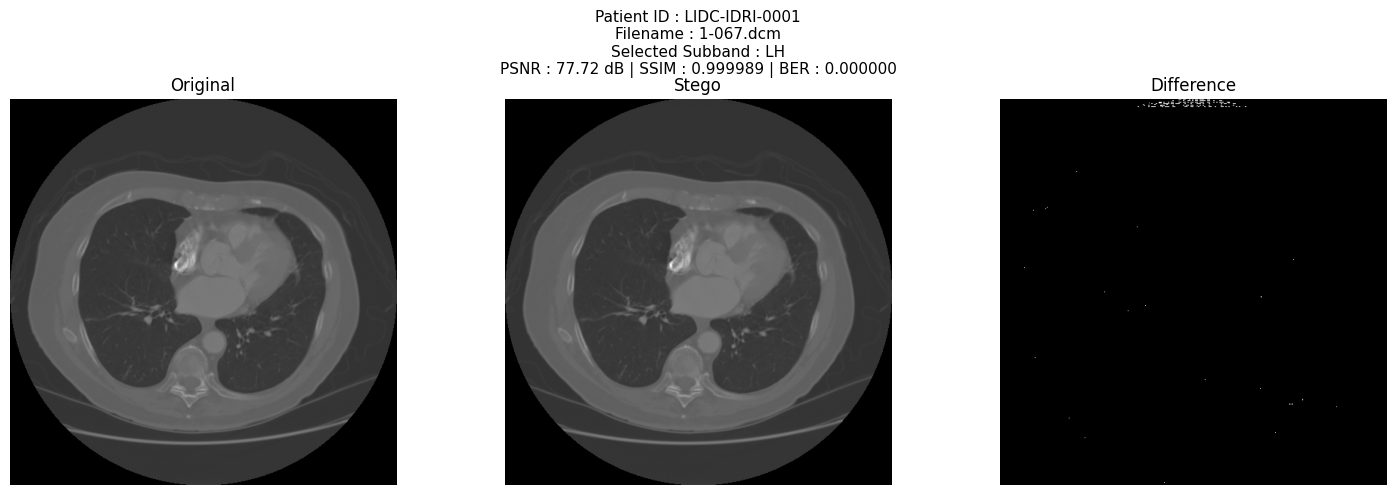

ORIGINAL METADATA
{
    "Patient ID": "LIDC-IDRI-0001",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -175.0,
    "Pixel Spacing": [
        0.703125,
        0.703125
    ]
}

EXTRACTED METADATA
{
    "Patient ID": "LIDC-IDRI-0001",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -175.0,
    "Pixel Spacing": [
        0.703125,
        0.703125
    ]
}

Extraction Status : SUCCESS


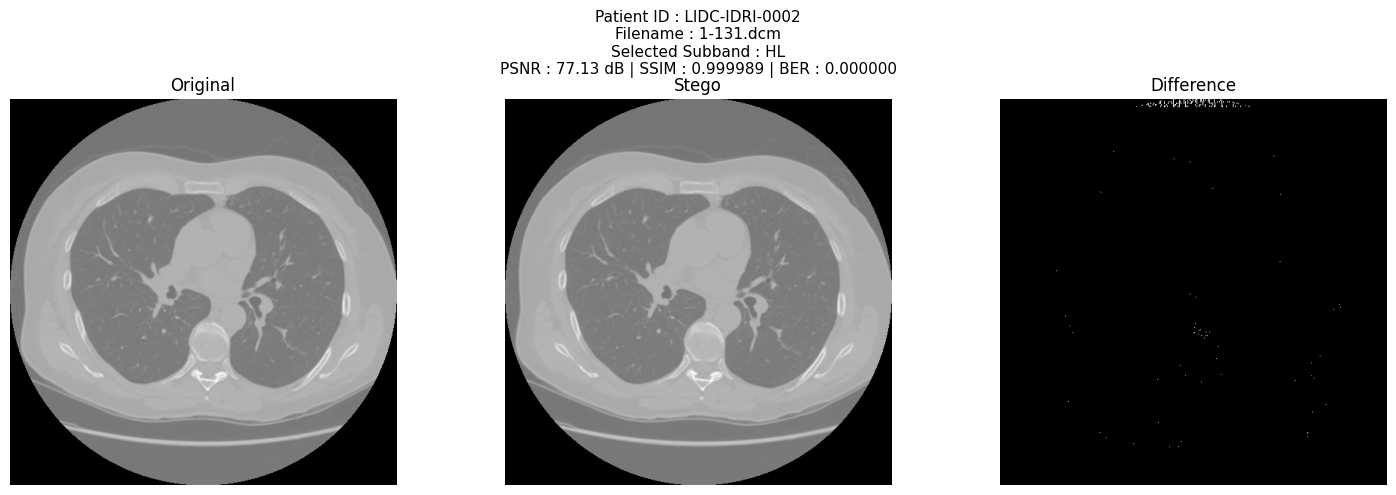

ORIGINAL METADATA
{
    "Patient ID": "LIDC-IDRI-0002",
    "Modality": "CT",
    "Slice Thickness": 1.25,
    "Slice Location": -172.0,
    "Pixel Spacing": [
        0.681641,
        0.681641
    ]
}

EXTRACTED METADATA
{
    "Patient ID": "LIDC-IDRI-0002",
    "Modality": "CT",
    "Slice Thickness": 1.25,
    "Slice Location": -172.0,
    "Pixel Spacing": [
        0.681641,
        0.681641
    ]
}

Extraction Status : SUCCESS


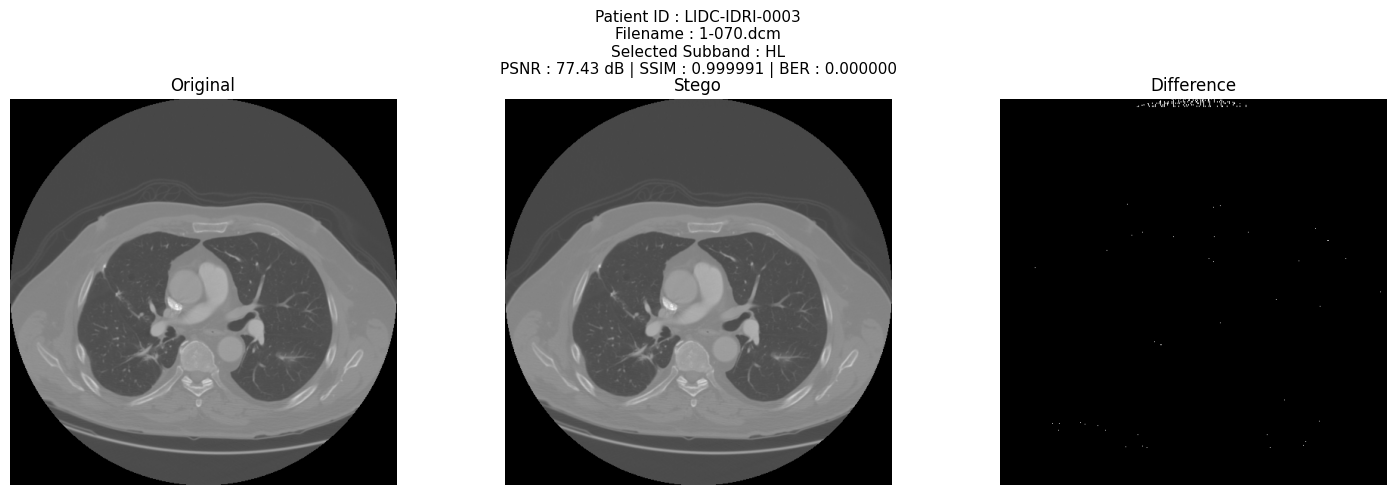

ORIGINAL METADATA
{
    "Patient ID": "LIDC-IDRI-0003",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -204.0,
    "Pixel Spacing": [
        0.820312,
        0.820312
    ]
}

EXTRACTED METADATA
{
    "Patient ID": "LIDC-IDRI-0003",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -204.0,
    "Pixel Spacing": [
        0.820312,
        0.820312
    ]
}

Extraction Status : SUCCESS


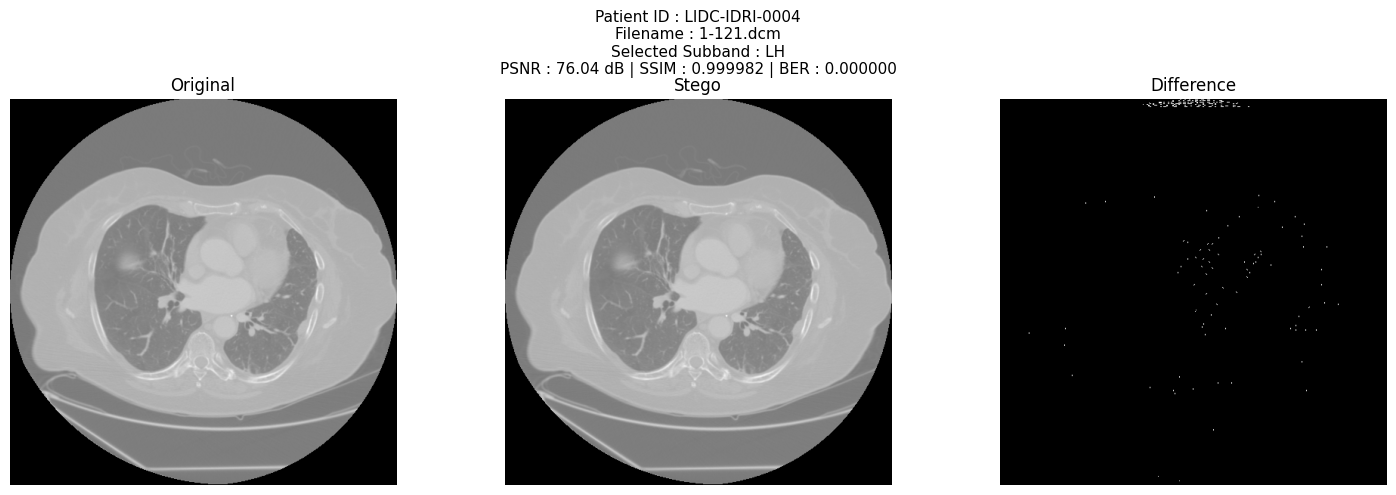

ORIGINAL METADATA
{
    "Patient ID": "LIDC-IDRI-0004",
    "Modality": "CT",
    "Slice Thickness": 1.25,
    "Slice Location": -175.0,
    "Pixel Spacing": [
        0.822266,
        0.822266
    ]
}

EXTRACTED METADATA
{
    "Patient ID": "LIDC-IDRI-0004",
    "Modality": "CT",
    "Slice Thickness": 1.25,
    "Slice Location": -175.0,
    "Pixel Spacing": [
        0.822266,
        0.822266
    ]
}

Extraction Status : SUCCESS


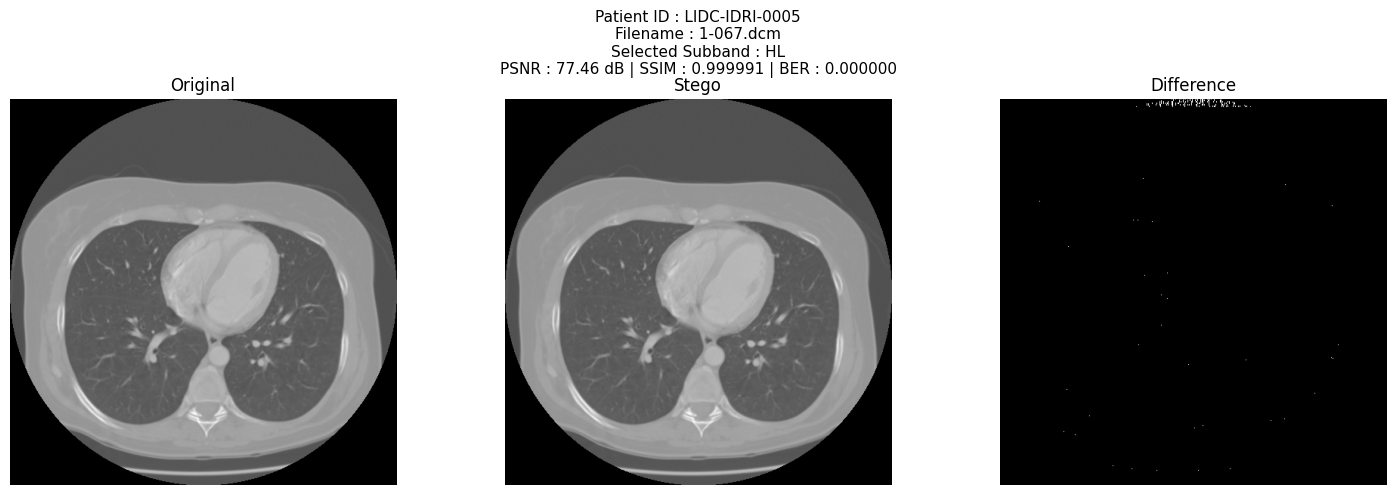

ORIGINAL METADATA
{
    "Patient ID": "LIDC-IDRI-0005",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -175.044998,
    "Pixel Spacing": [
        0.664062,
        0.664062
    ]
}

EXTRACTED METADATA
{
    "Patient ID": "LIDC-IDRI-0005",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -175.044998,
    "Pixel Spacing": [
        0.664062,
        0.664062
    ]
}

Extraction Status : SUCCESS


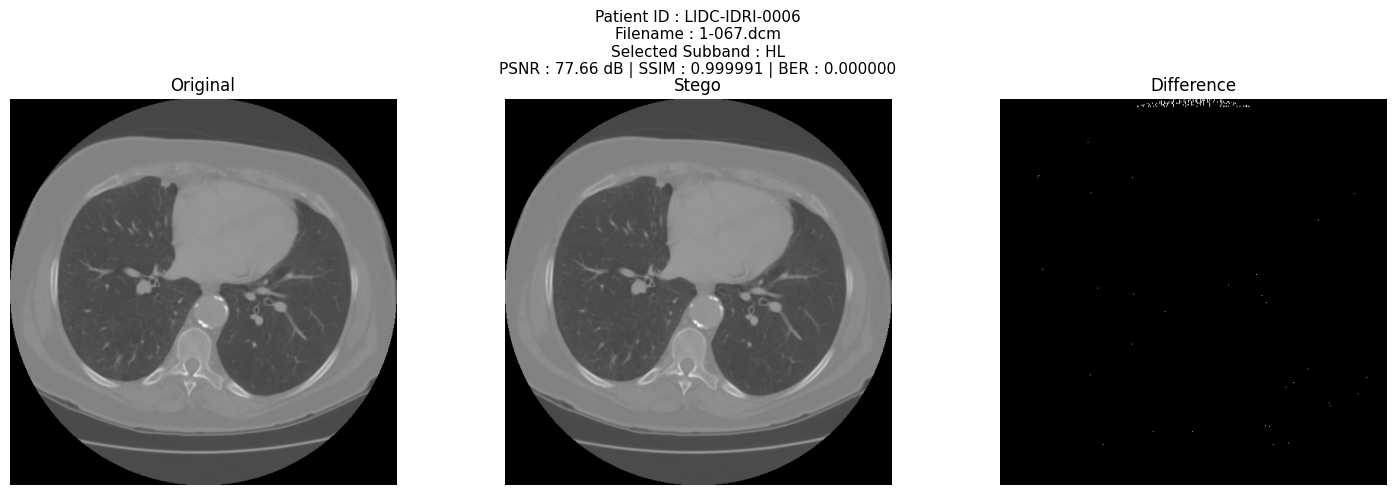

ORIGINAL METADATA
{
    "Patient ID": "LIDC-IDRI-0006",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -166.5,
    "Pixel Spacing": [
        0.625,
        0.625
    ]
}

EXTRACTED METADATA
{
    "Patient ID": "LIDC-IDRI-0006",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -166.5,
    "Pixel Spacing": [
        0.625,
        0.625
    ]
}

Extraction Status : SUCCESS


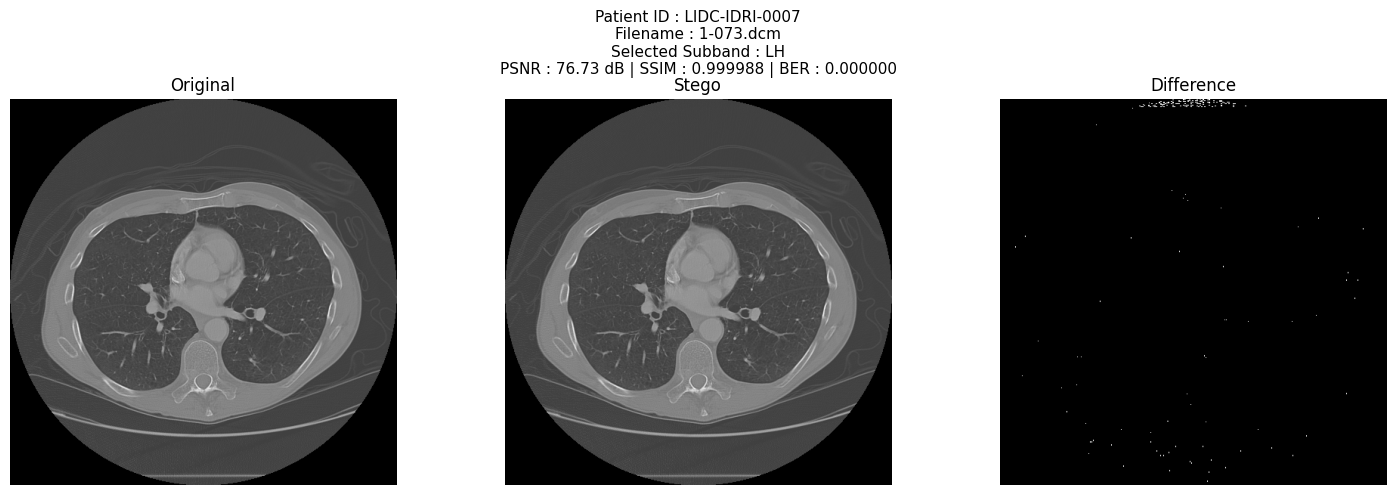

ORIGINAL METADATA
{
    "Patient ID": "LIDC-IDRI-0007",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -179.5,
    "Pixel Spacing": [
        0.78125,
        0.78125
    ]
}

EXTRACTED METADATA
{
    "Patient ID": "LIDC-IDRI-0007",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -179.5,
    "Pixel Spacing": [
        0.78125,
        0.78125
    ]
}

Extraction Status : SUCCESS


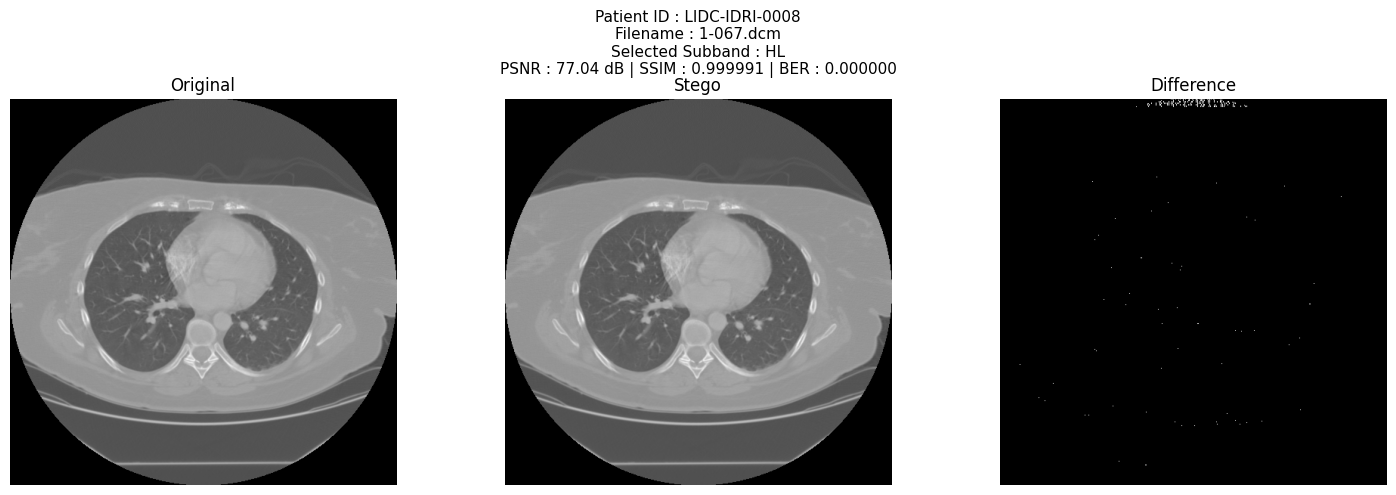

ORIGINAL METADATA
{
    "Patient ID": "LIDC-IDRI-0008",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -180.720001,
    "Pixel Spacing": [
        0.78125,
        0.78125
    ]
}

EXTRACTED METADATA
{
    "Patient ID": "LIDC-IDRI-0008",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -180.720001,
    "Pixel Spacing": [
        0.78125,
        0.78125
    ]
}

Extraction Status : SUCCESS


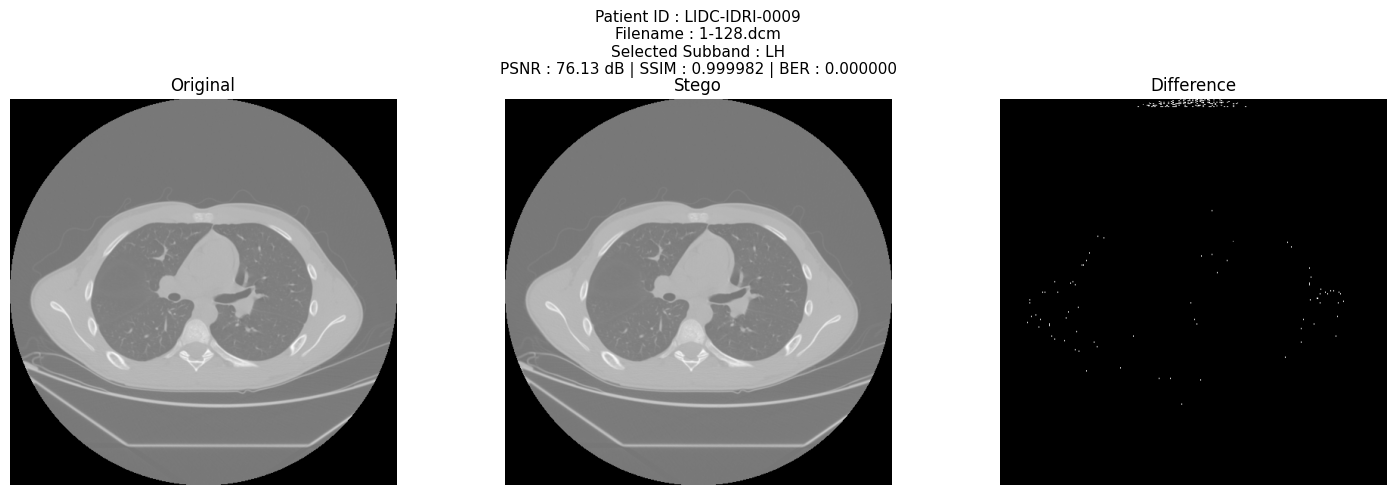

ORIGINAL METADATA
{
    "Patient ID": "LIDC-IDRI-0009",
    "Modality": "CT",
    "Slice Thickness": 1.25,
    "Slice Location": -165.0,
    "Pixel Spacing": [
        0.78125,
        0.78125
    ]
}

EXTRACTED METADATA
{
    "Patient ID": "LIDC-IDRI-0009",
    "Modality": "CT",
    "Slice Thickness": 1.25,
    "Slice Location": -165.0,
    "Pixel Spacing": [
        0.78125,
        0.78125
    ]
}

Extraction Status : SUCCESS


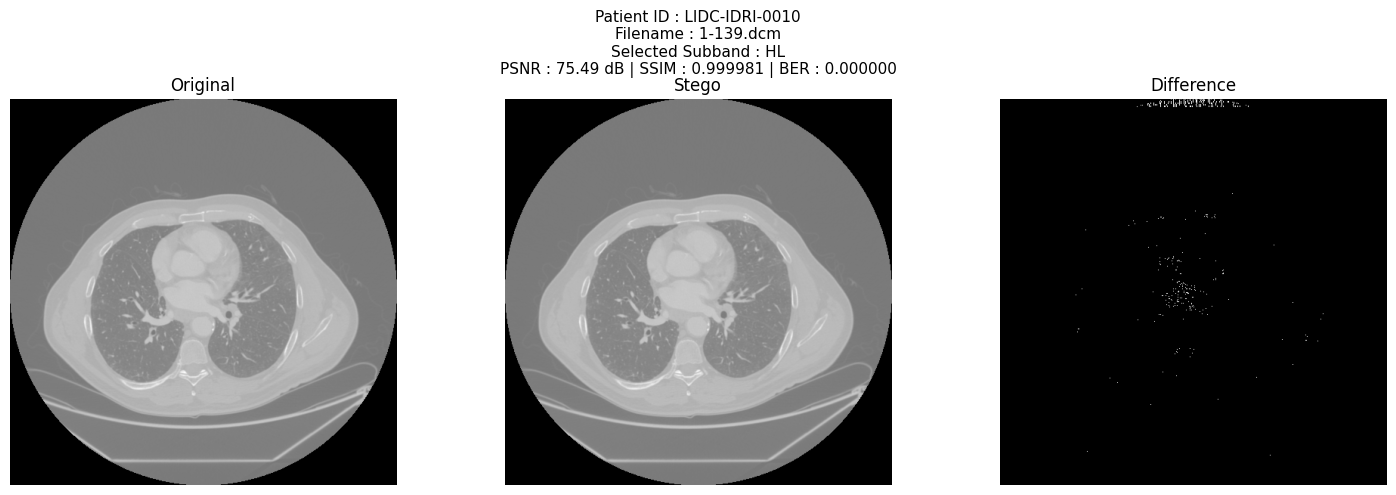

ORIGINAL METADATA
{
    "Patient ID": "LIDC-IDRI-0010",
    "Modality": "CT",
    "Slice Thickness": 1.25,
    "Slice Location": -162.5,
    "Pixel Spacing": [
        0.878906,
        0.878906
    ]
}

EXTRACTED METADATA
{
    "Patient ID": "LIDC-IDRI-0010",
    "Modality": "CT",
    "Slice Thickness": 1.25,
    "Slice Location": -162.5,
    "Pixel Spacing": [
        0.878906,
        0.878906
    ]
}

Extraction Status : SUCCESS


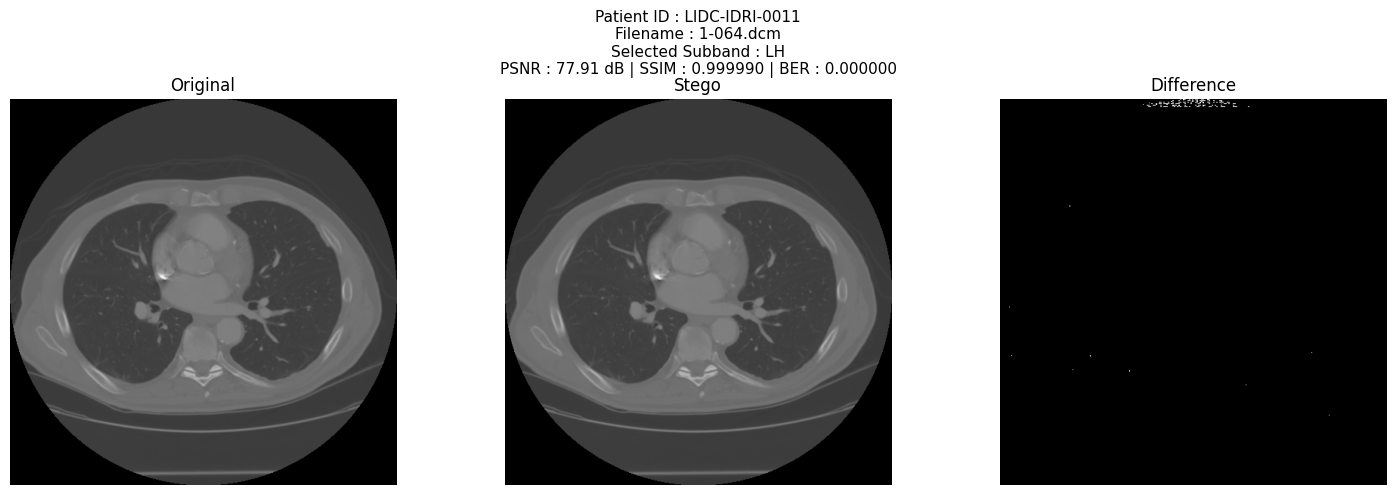

ORIGINAL METADATA
{
    "Patient ID": "LIDC-IDRI-0011",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -167.75,
    "Pixel Spacing": [
        0.742188,
        0.742188
    ]
}

EXTRACTED METADATA
{
    "Patient ID": "LIDC-IDRI-0011",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -167.75,
    "Pixel Spacing": [
        0.742188,
        0.742188
    ]
}

Extraction Status : SUCCESS


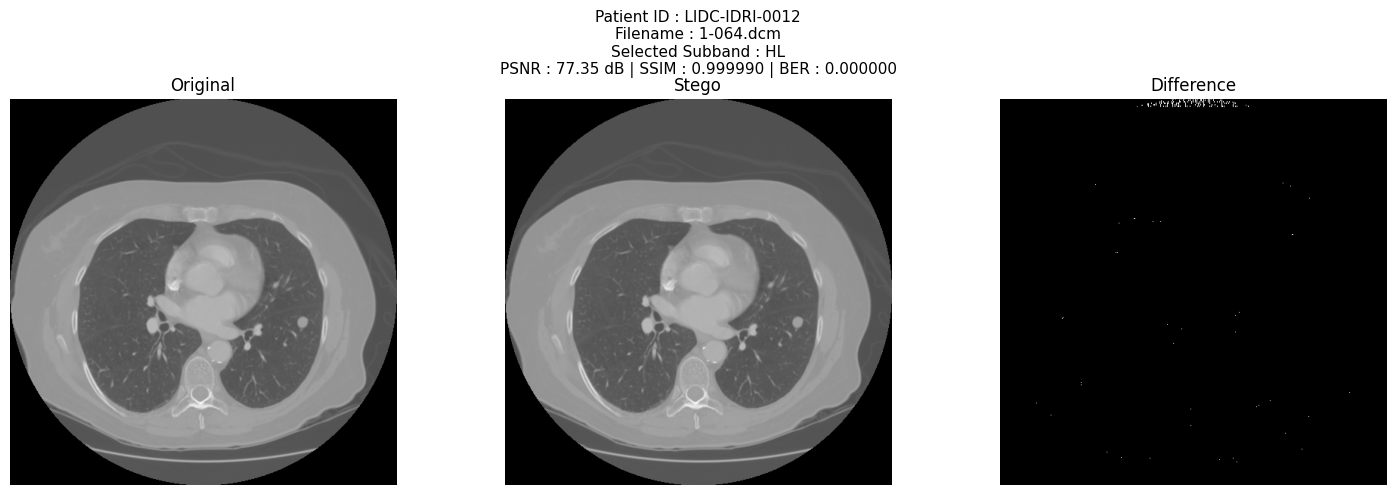

ORIGINAL METADATA
{
    "Patient ID": "LIDC-IDRI-0012",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -195.25,
    "Pixel Spacing": [
        0.742188,
        0.742188
    ]
}

EXTRACTED METADATA
{
    "Patient ID": "LIDC-IDRI-0012",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -195.25,
    "Pixel Spacing": [
        0.742188,
        0.742188
    ]
}

Extraction Status : SUCCESS


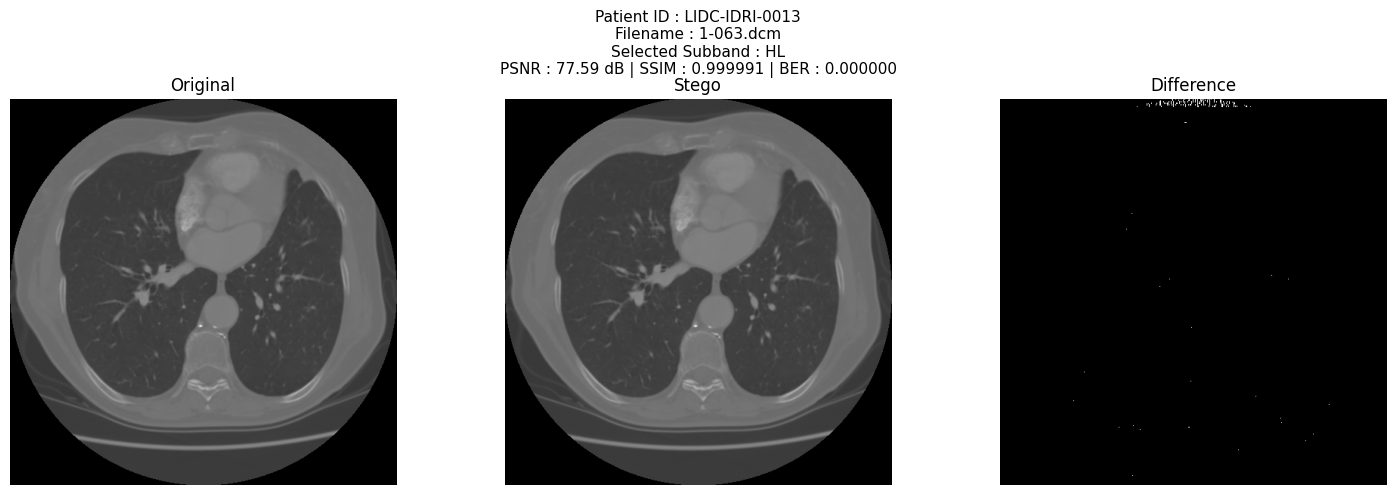

ORIGINAL METADATA
{
    "Patient ID": "LIDC-IDRI-0013",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -195.850006,
    "Pixel Spacing": [
        0.585938,
        0.585938
    ]
}

EXTRACTED METADATA
{
    "Patient ID": "LIDC-IDRI-0013",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -195.850006,
    "Pixel Spacing": [
        0.585938,
        0.585938
    ]
}

Extraction Status : SUCCESS


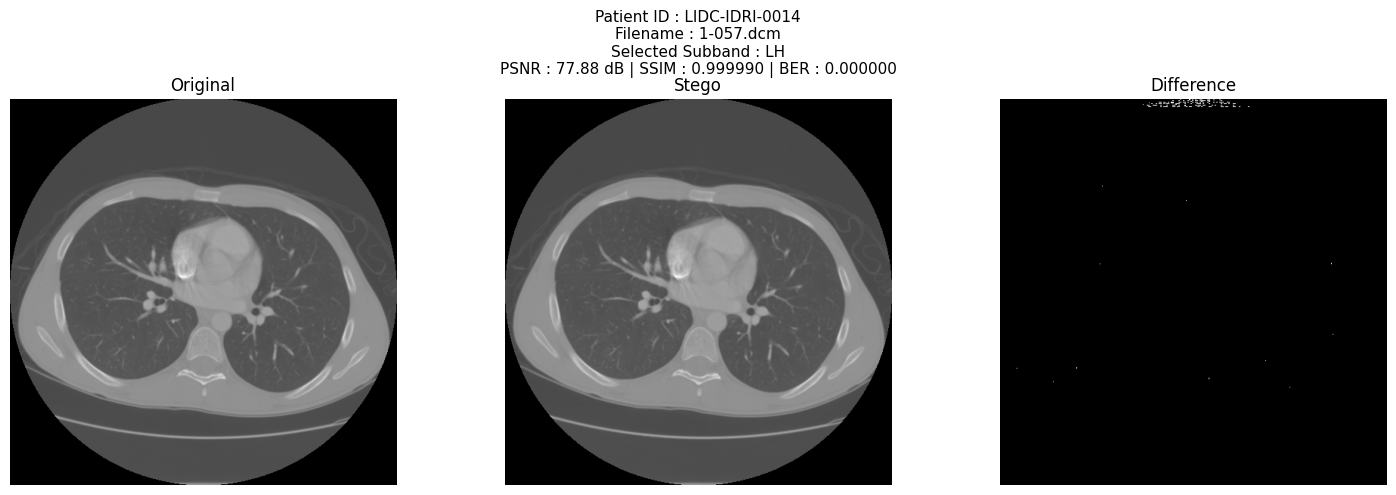

ORIGINAL METADATA
{
    "Patient ID": "LIDC-IDRI-0014",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -177.75,
    "Pixel Spacing": [
        0.664062,
        0.664062
    ]
}

EXTRACTED METADATA
{
    "Patient ID": "LIDC-IDRI-0014",
    "Modality": "CT",
    "Slice Thickness": 2.5,
    "Slice Location": -177.75,
    "Pixel Spacing": [
        0.664062,
        0.664062
    ]
}

Extraction Status : SUCCESS


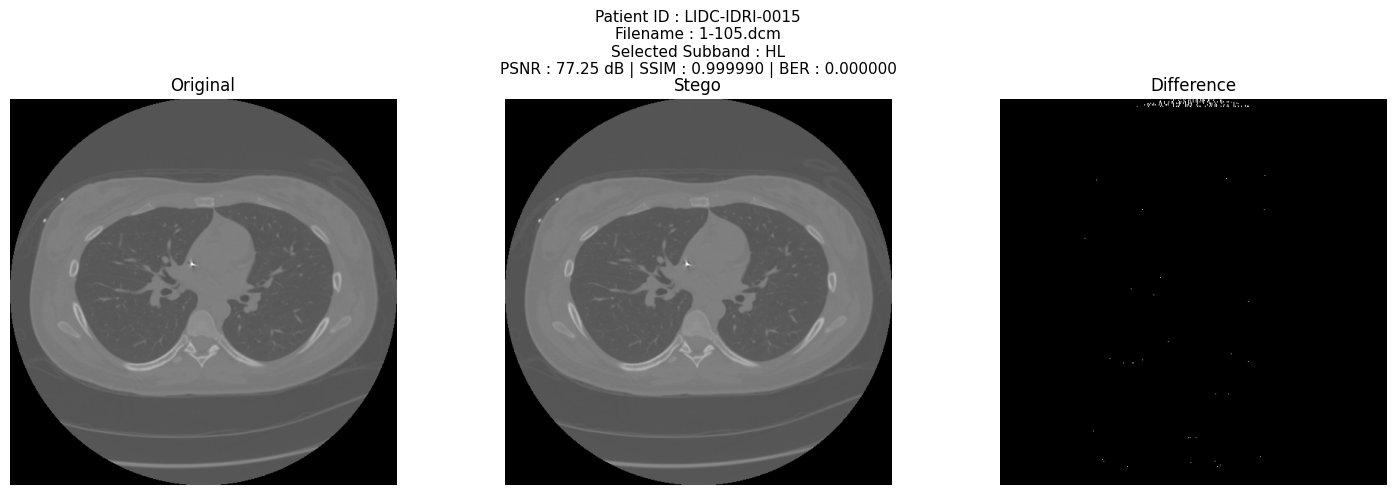

ORIGINAL METADATA
{
    "Patient ID": "LIDC-IDRI-0015",
    "Modality": "CT",
    "Slice Thickness": 1.25,
    "Slice Location": -149.75,
    "Pixel Spacing": [
        0.693359,
        0.693359
    ]
}

EXTRACTED METADATA
{
    "Patient ID": "LIDC-IDRI-0015",
    "Modality": "CT",
    "Slice Thickness": 1.25,
    "Slice Location": -149.75,
    "Pixel Spacing": [
        0.693359,
        0.693359
    ]
}

Extraction Status : SUCCESS


In [ ]:
def visualize_result(filepath):

    # LOAD DICOM

    dataset = preprocessing.load_dicom(filepath)

    image = preprocessing.get_pixel_array(dataset)

    metadata = preprocessing.extract_metadata(dataset)

    metadata_string = json.dumps(
        metadata,
        indent=4
    )
    # PREPROCESSING

    normalized_image = preprocessing.normalize_image(
        image
    )

    # DWT

    LL, LH, HL, HH = dwt.dwt_decompose(
        normalized_image
    )

    # ADAPTIVE SUBBAND

    selected_name, selected_subband = (
        adaptive.select_adaptive_subband(
            LH,
            HL
        )
    )

    # EMBEDDING

    payload = embedding.prepare_payload(
        metadata_string
    )

    scaled_subband = embedding.prepare_subband(
        selected_subband
    )

    embedded_scaled_subband = embedding.embed_lsb(
        scaled_subband,
        payload
    )

    embedded_subband = embedding.restore_subband(
        embedded_scaled_subband
    )

    # RECONSTRUCTION

    if selected_name == "LH":

        reconstructed = dwt.dwt_reconstruct(
            LL,
            embedded_subband,
            HL,
            HH
        )

    else:

        reconstructed = dwt.dwt_reconstruct(
            LL,
            LH,
            embedded_subband,
            HH
        )

    embedded_image = np.clip(
        reconstructed,
        0,
        255
    ).astype(np.uint8)

    # IMAGE QUALITY

    report = evaluation.evaluation_report(
        normalized_image,
        embedded_image
    )

    # EXTRACTION

    extracted_metadata = extraction.extract_metadata(
        embedded_subband
    )

    binary_stream = extraction.extract_lsb(
        embedded_subband
    )

    extracted_binary = extraction.extract_payload(
        binary_stream
    )

    original_binary = embedding.string_to_binary(
        metadata_string
    )

    ber = evaluation.calculate_ber(
        original_binary,
        extracted_binary
    )

    # DIFFERENCE IMAGE

    difference = np.abs(
        normalized_image.astype(np.int16)
        -
        embedded_image.astype(np.int16)
    )

    # DISPLAY IMAGE

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15,5)
    )

    axes[0].imshow(
        normalized_image,
        cmap="gray"
    )
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(
        embedded_image,
        cmap="gray"
    )
    axes[1].set_title("Stego")
    axes[1].axis("off")

    axes[2].imshow(
        difference,
        cmap="gray"
    )
    axes[2].set_title("Difference")
    axes[2].axis("off")

    fig.suptitle(

        f"Patient ID : {metadata['Patient ID']}\n"
        f"Filename : {os.path.basename(filepath)}\n"
        f"Selected Subband : {selected_name}\n"
        f"PSNR : {report['PSNR']:.2f} dB | "
        f"SSIM : {report['SSIM']:.6f} | "
        f"BER : {ber:.6f}",

        fontsize=11

    )

    plt.tight_layout()

    plt.show()

    # DISPLAY METADATA

    print("=" * 60)
    print("ORIGINAL METADATA")
    print("=" * 60)
    print(metadata_string)

    print()

    print("=" * 60)
    print("EXTRACTED METADATA")
    print("=" * 60)
    print(extracted_metadata)

    print()

    if metadata_string == extracted_metadata:

        print("Extraction Status : SUCCESS")

    else:

        print("Extraction Status : FAILED")

    print("=" * 60)


# REPRESENTATIVE FILES

def get_representative_files(file_list):

    representative_files = []

    visited_patients = set()

    for filepath in file_list:

        dataset = preprocessing.load_dicom(
            filepath
        )

        metadata = preprocessing.extract_metadata(
            dataset
        )

        patient_id = metadata["Patient ID"]

        if patient_id not in visited_patients:

            representative_files.append(
                filepath
            )

            visited_patients.add(
                patient_id
            )

    return representative_files


# PREVIEW REPRESENTATIVE RESULTS

print("REPRESENTATIVE RESULTS")

preview_files = get_representative_files(
    selected_files
)

for filepath in preview_files:

    visualize_result(filepath)

In [6]:
# SAVE LH-HL TEXTURE VISUALIZATION

texture_output = os.path.join(
    OUTPUT_PATH,
    SCENARIO,
    "texture_visualization"
)

os.makedirs(texture_output, exist_ok=True)

for i, filepath in enumerate(selected_files, start=1):

    # Load dan preprocessing
    dataset = preprocessing.load_dicom(filepath)
    image = preprocessing.get_pixel_array(dataset)
    metadata = preprocessing.extract_metadata(dataset)

    normalized_image = preprocessing.normalize_image(image)

    # DWT
    LL, LH, HL, HH = dwt.dwt_decompose(normalized_image)

    # Energy
    energies = energy.calculate_all_energies(
        LL, LH, HL, HH
    )

    # Buat figure untuk disimpan
    fig, axes = plt.subplots(
        1, 2,
        figsize=(10, 5)
    )

    axes[0].imshow(LH, cmap="gray")
    axes[0].set_title(
        f"LH\nEnergy = {energies['LH']:.2f}"
    )
    axes[0].axis("off")

    axes[1].imshow(HL, cmap="gray")
    axes[1].set_title(
        f"HL\nEnergy = {energies['HL']:.2f}"
    )
    axes[1].axis("off")

    fig.suptitle(
        f"{i}. {metadata['Patient ID']} | "
        f"{os.path.basename(filepath)}",
        fontsize=11
    )

    plt.tight_layout()

    # Nama file dibuat unik agar tidak overwrite
    base_name = os.path.splitext(
        os.path.basename(filepath)
    )[0]

    filename = (
        f"{metadata['Patient ID']}_"
        f"{base_name}_LH_HL.png"
    )

    save_path = os.path.join(
        texture_output,
        filename
    )

    fig.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

print("TEXTURE VISUALIZATION SAVED")
print(f"Total saved : {len(selected_files)}")
print(f"Folder      : {texture_output}")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ==========================================================
# EMBEDDED METADATA PREVIEW
# ==========================================================

metadata_rows = []

for filepath in selected_files:

    dataset = preprocessing.load_dicom(filepath)

    metadata = preprocessing.extract_metadata(dataset)

    metadata_rows.append({

        "Filename": os.path.basename(filepath),

        "Patient ID": metadata["Patient ID"],

        "Modality": metadata["Modality"],

        "Slice Thickness": metadata["Slice Thickness"],

        "Slice Location": metadata["Slice Location"],

        "Pixel Spacing": metadata["Pixel Spacing"]

    })

metadata_df = pd.DataFrame(metadata_rows)

display(metadata_df)

,Filename,Patient ID,Modality,Slice Thickness,Slice Location,Pixel Spacing
0,1-067.dcm,LIDC-IDRI-0001,CT,2.50,-175.000000,"[0.703125, 0.703125]"
1,1-131.dcm,LIDC-IDRI-0002,CT,1.25,-172.000000,"[0.681641, 0.681641]"
2,1-070.dcm,LIDC-IDRI-0003,CT,2.50,-204.000000,"[0.820312, 0.820312]"
3,1-121.dcm,LIDC-IDRI-0004,CT,1.25,-175.000000,"[0.822266, 0.822266]"
4,1-067.dcm,LIDC-IDRI-0005,CT,2.50,-175.044998,"[0.664062, 0.664062]"
5,1-067.dcm,LIDC-IDRI-0006,CT,2.50,-166.500000,"[0.625000, 0.625000]"
6,1-073.dcm,LIDC-IDRI-0007,CT,2.50,-179.500000,"[0.781250, 0.781250]"
7,1-067.dcm,LIDC-IDRI-0008,CT,2.50,-180.720001,"[0.781250, 0.781250]"
8,1-128.dcm,LIDC-IDRI-0009,CT,1.25,-165.000000,"[0.781250, 0.781250]"
9,1-139.dcm,LIDC-IDRI-0010,CT,1.25,-162.500000,"[0.878906, 0.878906]"


# EXPORT RESULTS

In [ ]:
# CREATE OUTPUT FOLDER

scenario_output = os.path.join(
    OUTPUT_PATH,
    SCENARIO
)

os.makedirs(
    scenario_output,
    exist_ok=True
)

# SAVE RESULTS DATAFRAME

results_path = os.path.join(
    scenario_output,
    "results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print("RESULTS DATAFRAME SAVED")
print(results_path)

# SAVE SUMMARY STATISTICS

summary_df = results_df.describe(
    include="all"
)

summary_path = os.path.join(
    scenario_output,
    "summary_statistics.csv"
)

summary_df.to_csv(
    summary_path
)

insight_df = utils.print_experiment_insight(
    results_df
)

insight_path = os.path.join(
    scenario_output,
    "experiment_insight.csv"
)

insight_df.to_csv(
    insight_path,
    index=False
)

print("EXPERIMENT INSIGHT SAVED")
print(insight_path)

print(f"EXPORT COMPLETED SUCCESSFULLY ({SCENARIO})")

RESULTS DATAFRAME SAVED
/content/drive/MyDrive/TugasAkhirKayla/Output/S2/results.csv
EXPERIMENT INSIGHT
Images Tested                 : 15
Successful Embedding          : 15
Failed Embedding              : 0
Average PSNR (dB)             : 77.1204
Average SSIM                  : 0.999988
Average BER                   : 0.0
Average Payload (bits)        : 1502.0
Average Capacity (bits)       : 65536.0
Average Utilization (%)       : 2.29

Selected Subband Distribution
Selected Subband
HL    9
LH    6
Name: count, dtype: int64
EXPERIMENT INSIGHT SAVED
/content/drive/MyDrive/TugasAkhirKayla/Output/S2/experiment_insight.csv
EXPORT COMPLETED SUCCESSFULLY (S2)


#
SAVE EXPERIMENT IMAGES

In [ ]:
IMAGE_SCENARIO = "S2"


# 1. LOAD CONFIGURATION

image_config = SCENARIOS[IMAGE_SCENARIO]

image_selected_files = load_dataset(
    DATASET_PATH,
    image_config
)

print("=" * 60)
print(f"SAVING IMAGES FOR {IMAGE_SCENARIO}")
print("=" * 60)

print(
    f"Total images : {len(image_selected_files)}"
)

# 2. CREATE OUTPUT FOLDERS

image_output = os.path.join(
    OUTPUT_PATH,
    IMAGE_SCENARIO,
    "images"
)

original_output = os.path.join(
    image_output,
    "original"
)

stego_output = os.path.join(
    image_output,
    "stego"
)

comparison_output = os.path.join(
    image_output,
    "comparison"
)

os.makedirs(
    original_output,
    exist_ok=True
)

os.makedirs(
    stego_output,
    exist_ok=True
)

os.makedirs(
    comparison_output,
    exist_ok=True
)

# 3. PROCESS AND SAVE IMAGES

for i, filepath in enumerate(
    image_selected_files,
    start=1
):

    print(
        f"[{i}/{len(image_selected_files)}] "
        f"{os.path.basename(filepath)}"
    )

    try:

        # LOAD DICOM

        dataset = preprocessing.load_dicom(
            filepath
        )

        image = preprocessing.get_pixel_array(
            dataset
        )

        metadata = preprocessing.extract_metadata(
            dataset
        )

        metadata_string = json.dumps(
            metadata,
            indent=4
        )

        # PREPROCESSING

        normalized_image = (
            preprocessing.normalize_image(
                image
            )
        )

        # DWT

        LL, LH, HL, HH = dwt.dwt_decompose(
            normalized_image
        )

        # ADAPTIVE SUBBAND

        selected_name, selected_subband = (
            adaptive.select_adaptive_subband(
                LH,
                HL
            )
        )


        # PREPARE PAYLOAD

        payload = embedding.prepare_payload(
            metadata_string
        )


        # PREPARE SUBBAND

        scaled_subband = (
            embedding.prepare_subband(
                selected_subband
            )
        )

        # EMBEDDING

        embedded_scaled_subband = (
            embedding.embed_lsb(
                scaled_subband,
                payload
            )
        )


        embedded_subband = (
            embedding.restore_subband(
                embedded_scaled_subband
            )
        )

        # RECONSTRUCTION

        if selected_name == "LH":

            reconstructed = (
                dwt.dwt_reconstruct(
                    LL,
                    embedded_subband,
                    HL,
                    HH
                )
            )

        else:

            reconstructed = (
                dwt.dwt_reconstruct(
                    LL,
                    LH,
                    embedded_subband,
                    HH
                )
            )


        embedded_image = np.clip(
            reconstructed,
            0,
            255
        ).astype(
            np.uint8
        )

        # FILE NAMES

        base_name = os.path.splitext(
            os.path.basename(filepath)
        )[0]

        original_filename = (
            f"{base_name}_original.png"
        )

        stego_filename = (
            f"{base_name}_stego.png"
        )

        comparison_filename = (
            f"{base_name}_comparison.png"
        )

        # SAVE ORIGINAL

        utils.save_image(
            normalized_image,
            original_filename,
            original_output
        )

        # SAVE STEGO

        utils.save_image(
            embedded_image,
            stego_filename,
            stego_output
        )

        # SAVE ORIGINAL VS STEGO

        utils.save_image_comparison(
            normalized_image,
            embedded_image,
            comparison_filename,
            comparison_output,
            title=(
                f"{IMAGE_SCENARIO} | "
                f"{base_name} | "
                f"Subband: {selected_name}"
            )
        )


    except Exception as e:

        print(
            f"ERROR: {str(e)}"
        )

# 4. FINISHED

print()
print("=" * 60)
print(
    f"IMAGE EXPORT COMPLETED ({IMAGE_SCENARIO})"
)
print("=" * 60)

print(
    f"Original images : {original_output}"
)

print(
    f"Stego images    : {stego_output}"
)

print(
    f"Comparison      : {comparison_output}"
)

SAVING IMAGES FOR S2
Total images : 15
[1/15] 1-067.dcm
[2/15] 1-131.dcm
[3/15] 1-070.dcm
[4/15] 1-121.dcm
[5/15] 1-067.dcm
[6/15] 1-067.dcm
[7/15] 1-073.dcm
[8/15] 1-067.dcm
[9/15] 1-128.dcm
[10/15] 1-139.dcm
[11/15] 1-064.dcm
[12/15] 1-064.dcm
[13/15] 1-063.dcm
[14/15] 1-057.dcm
[15/15] 1-105.dcm

IMAGE EXPORT COMPLETED (S2)
Original images : /content/drive/MyDrive/TugasAkhirKayla/Output/S2/images/original
Stego images    : /content/drive/MyDrive/TugasAkhirKayla/Output/S2/images/stego
Comparison      : /content/drive/MyDrive/TugasAkhirKayla/Output/S2/images/comparison


In [ ]:
# ==========================================================
# NORMALIZATION INSIGHT
# ==========================================================

normalization_rows = []

for i, filepath in enumerate(selected_files, start=1):

    dataset = preprocessing.load_dicom(filepath)

    image = preprocessing.get_pixel_array(dataset)

    metadata = preprocessing.extract_metadata(dataset)

    normalized_image = preprocessing.normalize_image(image)

    normalization_rows.append({
        "No.": i,
        "Patient ID": metadata["Patient ID"],
        "Filename": os.path.basename(filepath),
        "Dimensi": f"{image.shape[0]} × {image.shape[1]}",
        "Min Awal": image.min(),
        "Maks Awal": image.max(),
        "Min Hasil": normalized_image.min(),
        "Maks Hasil": normalized_image.max()
    })

normalization_df = pd.DataFrame(normalization_rows)

display(normalization_df)

,No.,Patient ID,Filename,Dimensi,Min Awal,Maks Awal,Min Hasil,Maks Hasil
0,1,LIDC-IDRI-0001,1-067.dcm,512 × 512,-1024,4095,0,255
1,2,LIDC-IDRI-0002,1-131.dcm,512 × 512,-2000,2368,0,255
2,3,LIDC-IDRI-0003,1-070.dcm,512 × 512,-1024,2695,0,255
3,4,LIDC-IDRI-0004,1-121.dcm,512 × 512,-2000,2185,0,255
4,5,LIDC-IDRI-0005,1-067.dcm,512 × 512,-1024,2262,0,255
5,6,LIDC-IDRI-0006,1-067.dcm,512 × 512,-1024,2772,0,255
6,7,LIDC-IDRI-0007,1-073.dcm,512 × 512,-1024,3020,0,255
7,8,LIDC-IDRI-0008,1-067.dcm,512 × 512,-1024,2288,0,255
8,9,LIDC-IDRI-0009,1-128.dcm,512 × 512,-2000,2276,0,255
9,10,LIDC-IDRI-0010,1-139.dcm,512 × 512,-2000,2206,0,255


In [ ]:
# ==========================================================
# PIXEL MATRIX BEFORE AND AFTER NORMALIZATION
# CENTRAL 6 × 6 REGION
# ==========================================================

# Pilih satu citra
filepath = selected_files[0]

# Load DICOM
dataset = preprocessing.load_dicom(filepath)

# Pixel array sebelum normalisasi
original_image = preprocessing.get_pixel_array(dataset)

# Normalisasi
normalized_image = preprocessing.normalize_image(
    original_image
)

# ==========================================================
# CENTER COORDINATES
# ==========================================================

rows, cols = original_image.shape

center_row = rows // 4
center_col = cols // 4

# Untuk ukuran 6 × 6
half_size = 3

row_start = center_row - half_size
row_end = center_row + half_size

col_start = center_col - half_size
col_end = center_col + half_size

# ==========================================================
# EXTRACT 6 × 6 MATRIX
# ==========================================================

original_6x6 = original_image[
    row_start:row_end,
    col_start:col_end
]

normalized_6x6 = normalized_image[
    row_start:row_end,
    col_start:col_end
]

# ==========================================================
# DISPLAY INFORMATION
# ==========================================================

print("=" * 60)
print("CENTRAL PIXEL MATRIX 6 × 6")
print("=" * 60)

print(f"Filename   : {os.path.basename(filepath)}")
print(f"Image Size : {rows} × {cols}")

print(
    f"Region     : rows {row_start}:{row_end - 1}, "
    f"columns {col_start}:{col_end - 1}"
)

print()

print("BEFORE NORMALIZATION")
print("-" * 60)
print(original_6x6)

print()

print("AFTER NORMALIZATION")
print("-" * 60)
print(normalized_6x6)

CENTRAL PIXEL MATRIX 6 × 6
Filename   : 1-067.dcm
Image Size : 512 × 512
Region     : rows 125:130, columns 125:130

BEFORE NORMALIZATION
------------------------------------------------------------
[[966 988 984 986 969 940]
 [971 959 949 943 928 923]
 [939 927 923 918 903 911]
 [914 915 922 912 903 904]
 [898 913 930 918 913 908]
 [903 914 915 896 899 902]]

AFTER NORMALIZATION
------------------------------------------------------------
[[ 99 100 100 100  99  97]
 [ 99  98  98  97  97  96]
 [ 97  97  96  96  95  96]
 [ 96  96  96  96  95  96]
 [ 95  96  97  96  96  96]
 [ 95  96  96  95  95  95]]


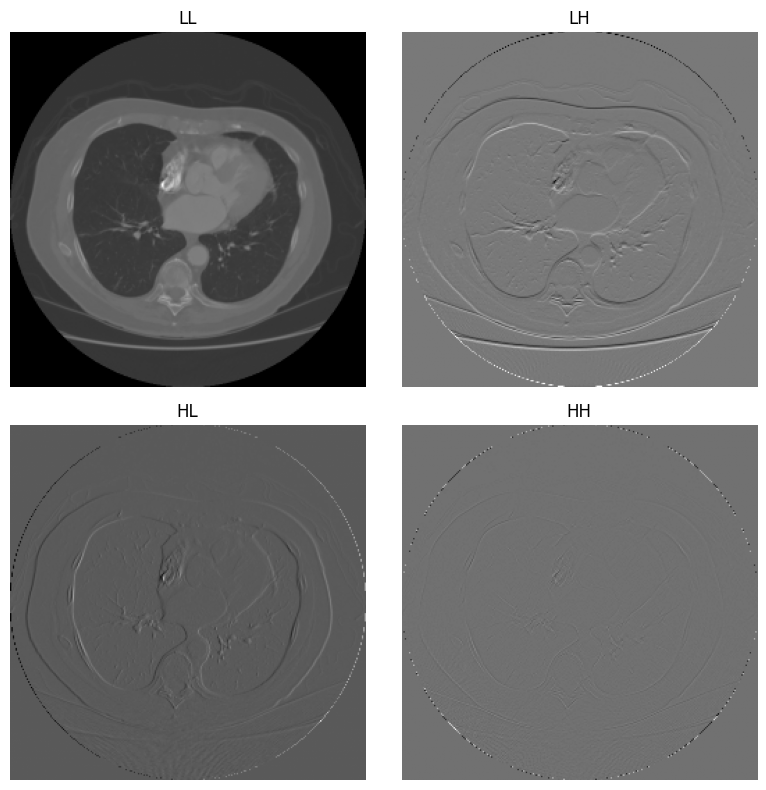

In [ ]:
# ==========================================================
# DWT LEVEL-1 DECOMPOSITION VISUALIZATION
# ==========================================================

# Pilih satu citra
filepath = selected_files[0]

# Load DICOM
dataset = preprocessing.load_dicom(filepath)

image = preprocessing.get_pixel_array(dataset)

# Preprocessing
normalized_image = preprocessing.normalize_image(
    image
)

# DWT decomposition
LL, LH, HL, HH = dwt.dwt_decompose(
    normalized_image
)

# ==========================================================
# DISPLAY FOUR SUBBANDS
# ==========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(8, 8)
)

# LL
axes[0, 0].imshow(
    LL,
    cmap="gray"
)
axes[0, 0].set_title("LL")
axes[0, 0].axis("off")

# LH
axes[0, 1].imshow(
    LH,
    cmap="gray"
)
axes[0, 1].set_title("LH")
axes[0, 1].axis("off")

# HL
axes[1, 0].imshow(
    HL,
    cmap="gray"
)
axes[1, 0].set_title("HL")
axes[1, 0].axis("off")

# HH
axes[1, 1].imshow(
    HH,
    cmap="gray"
)
axes[1, 1].set_title("HH")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

In [7]:
!pwd

/content


In [8]:
%cd /content/drive/MyDrive/TugasAkhirKayla

/content/drive/MyDrive/TugasAkhirKayla


In [9]:
!git status

Refresh index: 100% (12/12), done.
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   expbatch.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	TAAKAYY.drawio (1).png
	link github.gdoc

no changes added to commit (use "git add" and/or "git commit -a")


In [ ]:
!git add expbatch.ipynb
!git commit -m "add lh texture visualization"
!git push origin main

[main b9a261c] Run batch experiment for add insight for prepro
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite expbatch.ipynb (69%)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 280.64 KiB | 2.44 MiB/s, done.
Total 3 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Kaylamanda/TugasAkhirKayla.git
   3c90b6d..b9a261c  main -> main


In [ ]:
!git config --global user.email "kayla.122450086@student.itera.ac.id"
!git config --global user.name "Kaylamanda"